# Анализ и загрузка данных

Скачаем необходимые библиотеки

In [1]:
!pip install -q catboost category-encoders optuna phik git+https://github.com/jundongl/scikit-feature.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 20.9 MB/s eta 0:00:00


Импортируем необходимые библиотеки

In [73]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import phik

from category_encoders import CatBoostEncoder

from skfeature.function.statistical_based import CFS

from optuna import create_study
from optuna.distributions import IntDistribution, FloatDistribution
from optuna.logging import ERROR, INFO, set_verbosity, WARNING
from optuna.samplers import TPESampler

from catboost import CatBoostClassifier, CatBoostRegressor

from scipy.optimize import minimize

from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import ARDRegression
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from typing import Iterable

random_state = 42

Загрузим данные о персональных данных и неких психических характеристик 1200 людей. В общем будет предсказываться уровень депрессии человека с помощью моделей порядковой классификации (регрессии)

In [74]:
df = pd.read_csv('anxiety_depression_data.csv')
df = pd.concat([
    df.drop(columns='Depression_Score'),
    df['Depression_Score']
], axis=1)
df

,Age,Gender,Education_Level,Employment_Status,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Stress_Level,Family_History_Mental_Illness,...,Medication_Use,Therapy,Meditation,Substance_Use,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score,Depression_Score
0,56,Male,Bachelor's,Unemployed,6.0,0.4,3,4,9,0,...,NaN,0,1,NaN,4,3,7,5,1,2
1,69,Female,Bachelor's,Retired,8.8,2.8,6,18,6,0,...,NaN,1,0,NaN,1,4,7,4,6,7
2,46,Female,Master's,Employed,5.3,1.6,5,5,8,0,...,NaN,0,1,NaN,8,7,8,1,1,13
3,32,Female,High School,Unemployed,8.8,0.5,4,6,4,1,...,NaN,0,0,NaN,7,4,8,4,4,3
4,60,Female,Bachelor's,Retired,7.2,0.7,2,7,3,0,...,NaN,1,1,Frequent,8,9,5,7,7,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,23,Female,Other,Student,5.1,0.1,7,16,5,1,...,Occasional,0,0,NaN,2,8,7,6,5,15
1196,43,Female,Master's,Employed,8.9,0.4,9,19,9,0,...,NaN,0,1,NaN,8,9,7,6,4,4
1197,71,Female,PhD,Retired,6.0,0.1,2,15,2,0,...,NaN,0,1,NaN,2,9,9,3,7,4
1198,21,Male,Other,Employed,8.5,2.7,8,12,2,1,...,NaN,0,0,NaN,8,5,1,3,7,20


Напишем функцию для графика отрисовки зависимости некоторых численных признаков от уровня депрессии в виде шестиугольных ячеек

In [ ]:
def plot_hexbin_plots(
    df,
    features,
    y='Depression_Score',
    nrows=1,
    ncols=1,
    figsize=(15, 5),
    gridsize=20,
    cmap='Reds',
    mincnt=1
):
    axes = plt.subplots(figsize=figsize, nrows=nrows, ncols=ncols)[1]
    if nrows * ncols == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    for feature, ax in zip(features, axes):
        image = ax.hexbin(
            df[feature],
            df[y],
            gridsize=gridsize,
            cmap=cmap,
            mincnt=mincnt
        )
        plt.colorbar(image, label='Количество точек')
        ax.set_xlabel(feature)
        ax.set_ylabel(y)
    plt.suptitle('График с шестиугольными ячейками')
    plt.show()

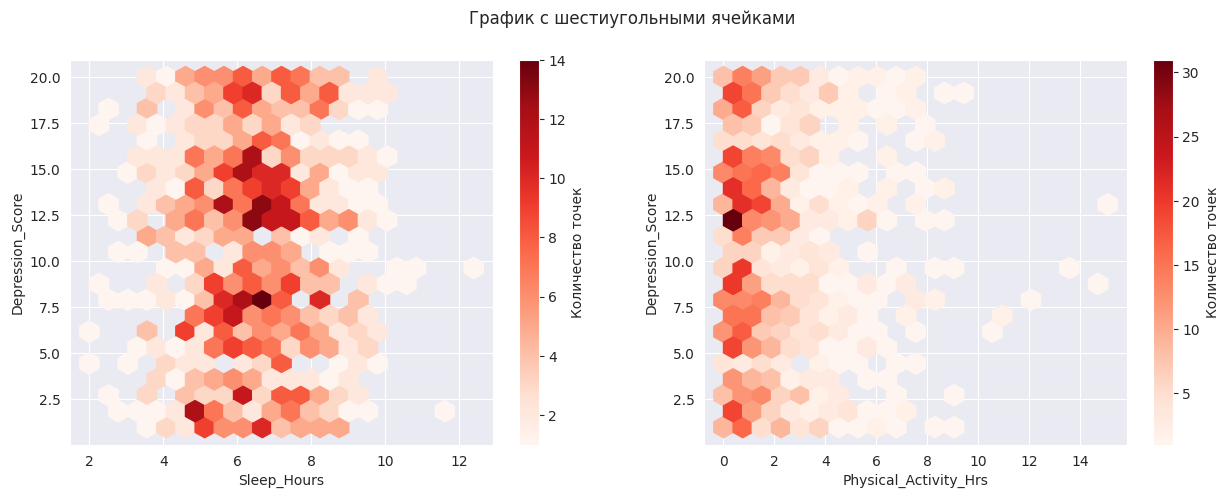

In [ ]:
plot_hexbin_plots(df, ['Sleep_Hours', 'Physical_Activity_Hrs'], ncols=2)

Не видно чёткой зависимости между силой депрессии и часами сна и физической активности

Следующая функция подсчитывает взаимное количество пар значений категориальных признаков и признака силы депрессии

In [ ]:
def plot_heatmaps(
    df,
    features,
    y='Depression_Score',
    nrows=1,
    ncols=1,
    figsize=(20, 15),
    gridsize=20,
    cmap='Reds',
    mincnt=1
):
    axes = plt.subplots(figsize=figsize, nrows=nrows, ncols=ncols)[1]
    if nrows * ncols == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    for feature, ax in zip(features, axes):
        sns.heatmap(
            df.pivot_table(
                index=feature,
                columns=y,
                aggfunc='size',
                fill_value=0
            ),
            annot=True,
            fmt='d',
            ax=ax
        )
    plt.suptitle('График тепловых карт')
    plt.tight_layout()
    plt.show()

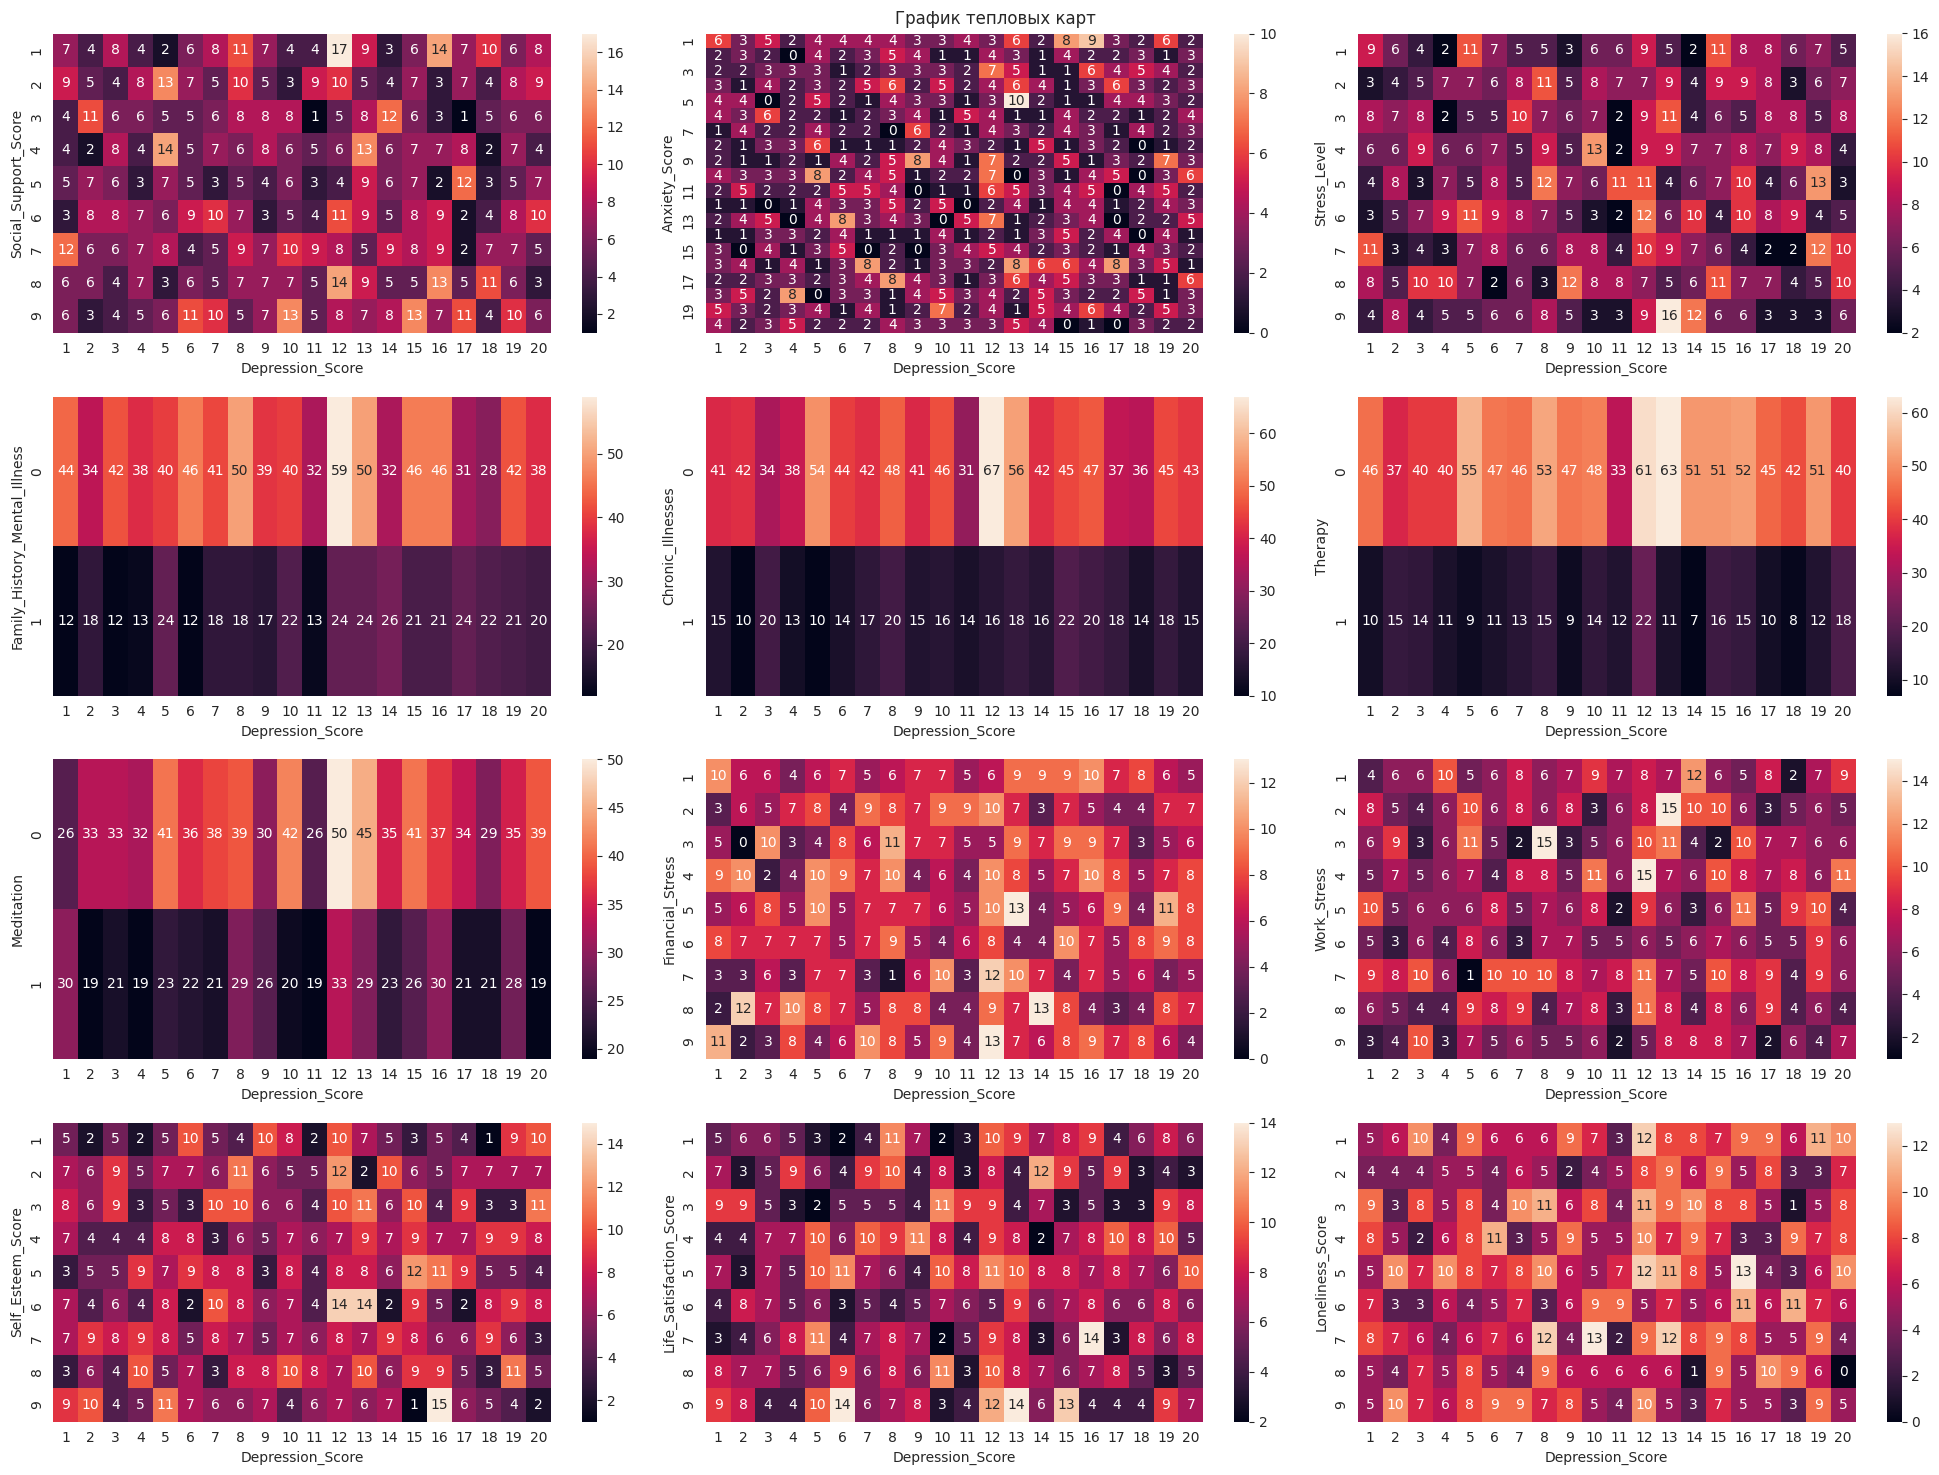

In [ ]:
plot_heatmaps(
    df,
    [
        'Social_Support_Score',
        'Anxiety_Score',
        'Stress_Level',
        'Family_History_Mental_Illness',
        'Chronic_Illnesses',
        'Therapy',
        'Meditation',
        'Financial_Stress',
        'Work_Stress',
        'Self_Esteem_Score',
        'Life_Satisfaction_Score',
        'Loneliness_Score'
    ],
    nrows=4,
    ncols=3
)

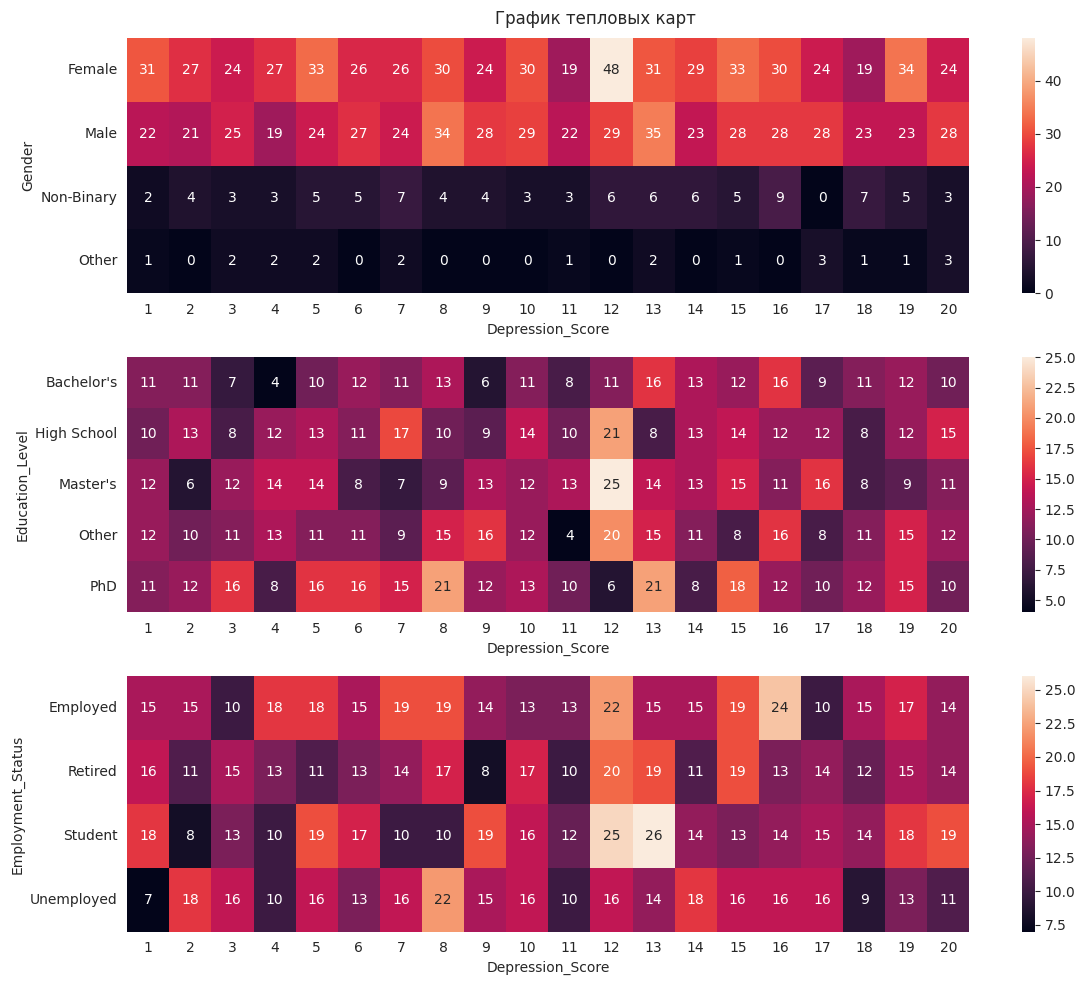

In [ ]:
plot_heatmaps(
    df,
    ['Gender', 'Education_Level', 'Employment_Status'],
    nrows=3,
    figsize=(12, 10)
)

Здесь тоже ничего определённого сказать нельзя

Эта функция нужна для отрисовки различных матриц phik

In [ ]:
def plot_phik(
    phik_matrix,
    significance_matrix,
    fmt='.3f',
    figsize=(15, 15)
):
    axes = plt.subplots(nrows=2, figsize=figsize)[1]
    sns.heatmap(phik_matrix, annot=True, fmt=fmt, cmap='RdBu', ax=axes[0])
    sns.heatmap(
        significance_matrix,
        annot=True,
        fmt=fmt,
        cmap='Greens',
        ax=axes[1]
    )
    axes[0].set_title('Коэффициент Phik')
    axes[1].set_title('Значимость коэффициента Phik')
    plt.tight_layout()
    plt.show()

Найдём численные и категориальные столбцы

In [75]:
number_columns = list(df.select_dtypes(include='number').columns)
categorical_columns = list(df.select_dtypes(include='object').columns)

Посчитаем 2 матрицы:
- Матрицу нелинейных корреляций phik
- Матрицу достоверности коэффициентов из предыдущей матрицы

In [ ]:
%%time
phik_matrix = df.phik_matrix(interval_cols=number_columns, quantile=True)
significance_matrix = df.significance_matrix(interval_cols=number_columns)

CPU times: user 12.9 s, sys: 943 ms, total: 13.8 s
Wall time: 2min 12s


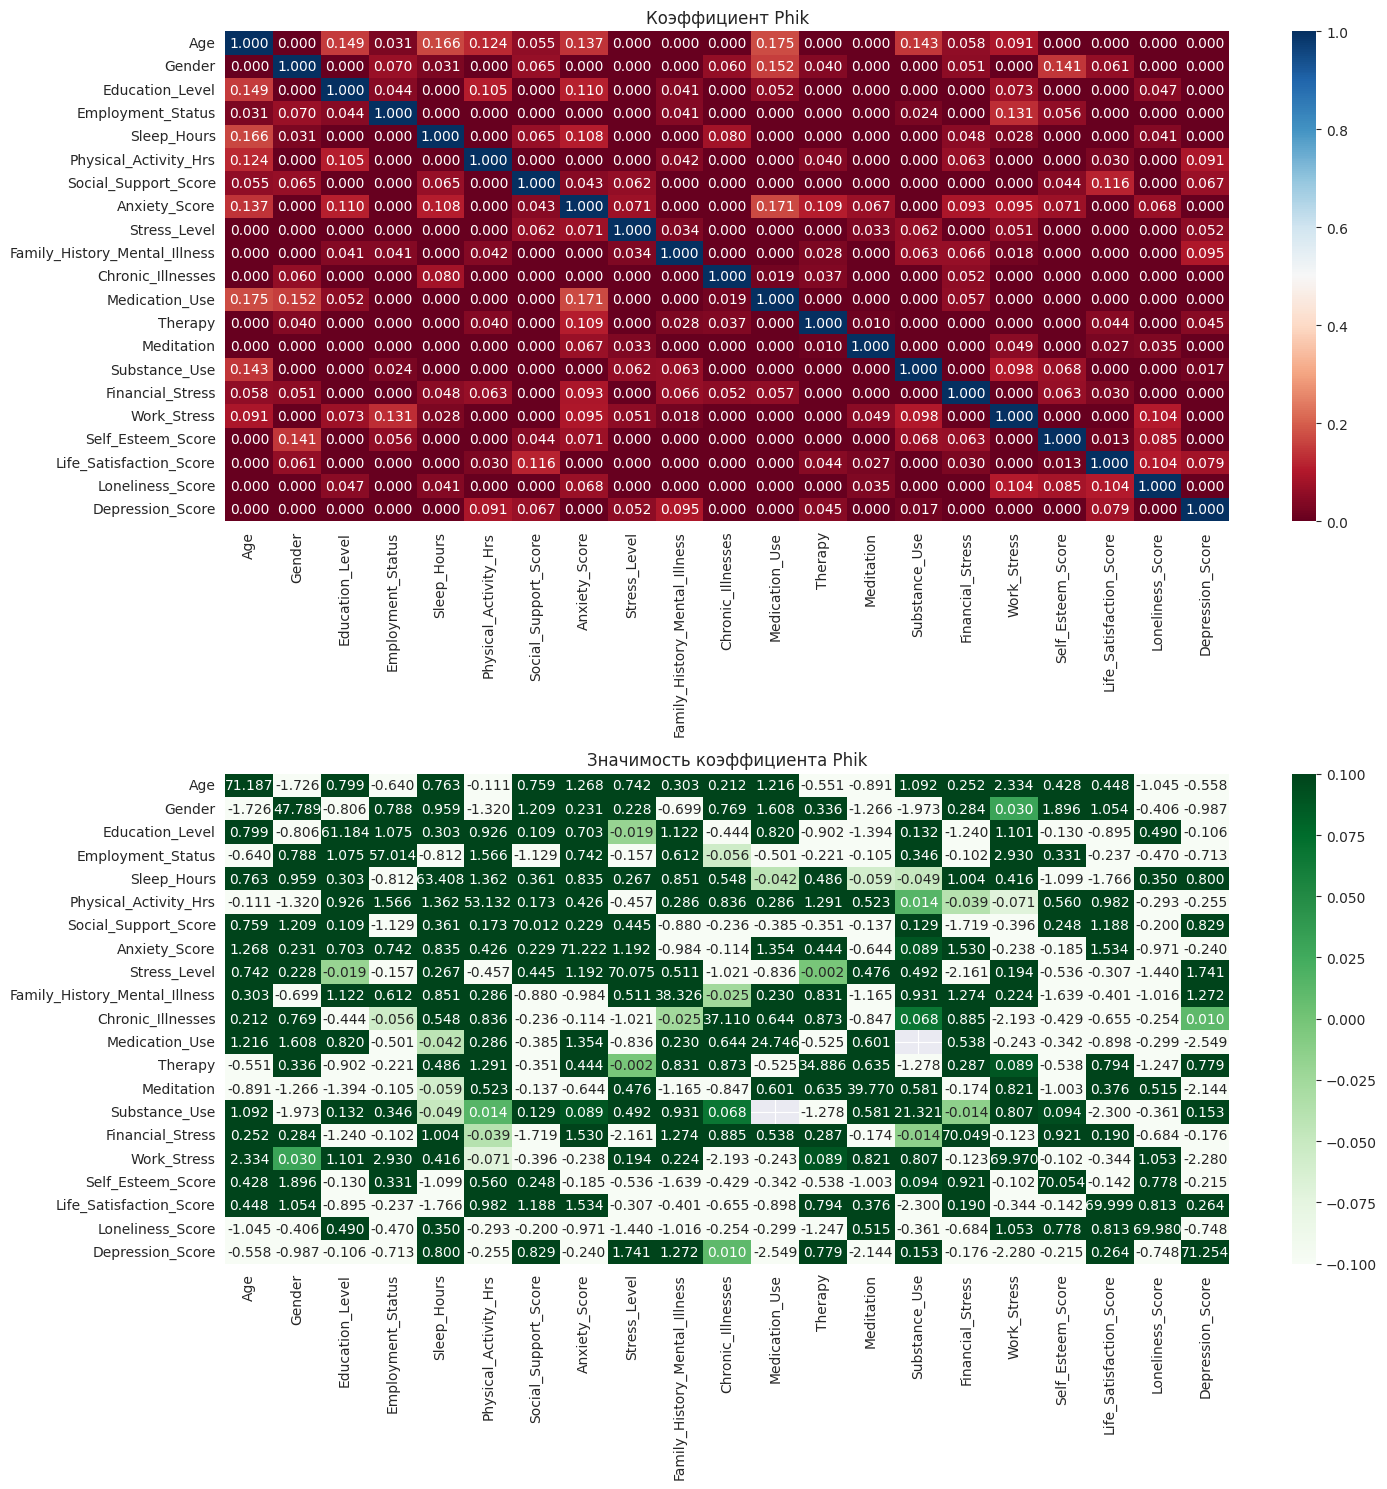

In [ ]:
plot_phik(phik_matrix, significance_matrix)

Видим, что значимых корреляций помимо диагонали нет. С целевой переменной наиболее сильно коррелируют:
- Количество часов физической активности
- Сила социальной поддержки
- Уровень стресса
- История семейных болезней
- Находится ли человек в терапии
- Употребление психоактивных веществ
- Степень довольности жизнью

В датасете используется госпитальная шкала тревоги и депрессии, в которой может быть максимум 21 балл. У показателей депрессии и тревоги следующая разбалловка:
- 0-3 балла - норма
- 4-8 баллов - лёгкая степень
- 9-14 баллов - средняя степень
- 15-21 балл - тяжёлая степень
Надо будет перевести эти шкалы в надлежащий вид, а также заполнить пропуски в признаках медитации и употребления веществ специальным значннием "Unknown"

Дополнительно надо разделить выборку на тренировочную, валидационную и тестовую выборки

In [76]:
df['Anxiety_Score'] = df['Anxiety_Score'].apply(
    lambda x: 1 if x <= 3 else 2 if x <= 8 else 3 if x <= 14 else 4
)
df['Depression_Score'] = df['Depression_Score'].apply(
    lambda x: 1 if x <= 3 else 2 if x <= 8 else 3 if x <= 14 else 4
)

df['Medication_Use'] = df['Medication_Use'].fillna('Unknown')
df['Substance_Use'] = df['Substance_Use'].fillna('Unknown')

df_train_and_valid, df_test = train_test_split(
    df,
    test_size=1/6,
    random_state=random_state,
    stratify=df['Depression_Score']
)
df_train, df_valid = train_test_split(
    df_train_and_valid,
    test_size=0.2,
    random_state=random_state,
    stratify=df_train_and_valid['Depression_Score']
)
X_train, y_train = (
    df_train.drop(columns='Depression_Score'),
    df_train['Depression_Score']
)
X_valid, y_valid = (
    df_valid.drop(columns='Depression_Score'),
    df_valid['Depression_Score']
)
X_test, y_test = (
    df_test.drop(columns='Depression_Score'),
    df_test['Depression_Score']
)

Создадим копию тренировочной выборки и закодируем категориальные столбцы CatBoost-кодировщиком, она понадобится для обучения регрессии для отбора признаков на следующем шаге

In [77]:
copy = X_train.copy()
copy.loc[:, categorical_columns] = CatBoostEncoder().fit_transform(
    copy[categorical_columns], y_train
)
copy.loc[:] = StandardScaler().fit_transform(copy)

/tmp/ipykernel_2693/1102058782.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.08669268 -1.49334633  0.2191016  -0.33132809 -1.30986977 -1.06523435
 -1.18755206 -0.75944008 -0.02553382  0.46373701 -0.08669268  1.38111983
  1.19764327 -0.14785153  1.44227869  0.64721358 -0.20901039 -0.33132809
 -0.75944008  1.19764327  0.52489587 -0.02553382  0.2191016   0.15794274
  0.28026045 -0.94291664 -1.43218747  1.25880212  1.44227869  1.44227869
 -1.00407549  0.2191016   1.19764327  0.03562503  0.76953129  1.25880212
  0.03562503  1.31996098 -0.20901039 -1.61566404  0.28026045  1.31996098
 -0.75944008  0.64721358 -0.69828122  1.07532556 -0.51480466  1.13648441
 -0.20901039 -1.18755206 -1.24871091 -0.39248695  1.31996098  0.34141931
  1.50343754  0.891849   -1.1263932  -1.24871091 -0.69828122  1.13648441
 -0.82059893 -1.43218747 -0.63712237  0.76953129 -0.57596351  1.50343754
 -0.39248695 -1.61566404  0.15794274 -1.43

Теперь перейдём к методам отбора признаков - первый из них это CFS (Correlation-based Feature Selection). Основная его идея заключаетя в том, что хорошее подмножество признаков содержит признаки, сильно коррелирующие с целевой переменной, но слабо коррелирующие между собой. То есть еси есть оба признака, сильно коррелирующие с целевой переменной, но при этом же сильно коррелирующие между собой, то один из этих признаков избыточен

Для оценки качества (ценности) подмножества из $\large{k}$ признаков CFS использует формулу, представленную ниже:
$$\large{M_s=\frac{k\cdot \overline{r}_{fs}}{\sqrt{k+k(k-1)\overline{r}_{ff}}},}$$
где:
- $\large{M_S}$ (Merit of Subset $\large{S}$) — итоговая оценка («ценность») подмножества $\large{S}$.
- $\large{k}$ — количество признаков в оцениваемом подмножестве
- $\large{\bar{r}_{cf}}$ (Feature-Class correlation) — средняя корреляция признаков из $\large{S}$ с целевой переменной $\large{y}$ (компонент полезности)
- $\large{\bar{r}_{ff}}$ (Feature-Feature correlation) — средняя взаимная корреляция между признаками внутри $\large{S}$ (компонент избыточности)

Чем сильнее признаки связаны с целевой переменной $\large{y}$, тем выше $\large{M_S}$ и наоборот, Чем сильнее признаки связаны между собой, тем больше знаменатель и тем ниже $\large{M_S}$

Для измерения связи используются симметричная неопределенность (Symmetrical Uncertainty, SU) на основе теории информации (энтропии), это позволяет находить нелинейные связи между переменными:
$$\large{SU(X,Y)=2\frac{IG(X,Y)}{H(X)+H(Y)},}$$
где:
- $\large{IG(X,Y)}$ - прирост информации
- $\large{H(X), H(Y)}$ - энтропии

Так как число всех подмножеств исходных признаков растёт экспоненциально, то алгоритм CFS не перебирает всё, а обычно использует жаный поиск вперёд:
1) Начинаем с пустого набора признаков
2) Поочерёдно добавляем признак, который максимально увеличивает $\large{M_S}$
3) Ели добавление новых признаков перестаёт увеличивать $\large{M_S}$ в течение нескольких шагов, алгоритм отаналивается и возвращает наилучший набор

В качестве плюсов алгоритма можно отметить:
- Быстрый фильтрующий метод (не требует обучения тяжелых ML-моделей)
- Автоматически определяет не только какие признаки взять, но и сколько их должно быть
- Эффективно удаляет дублирующие и мультиколлинеарные признаки

Сушественным же минусом алгоритма является то, что он не видит сложных комбинаций, где признаки полезны только вместе, но бесполезны по отдельности


Вторым методом отбора является встроенный метод в модель ARD (Automatic Relevance Determination). Это байесовский подход к линейной регрессии, который автоматически отбирает значимые признаки в процессе обучения

Для начала поясним за байесовскую гребневую регрессию - онаредполагает, что все веса $\large{w_j}$ имеют одинаковое априорное распределение с единым параметром точности (обратной дисперсии) $\large{\alpha}$:
$$\large{w_j \sim \mathcal{N}(0, \alpha^{-1})}$$

Здесь гиперпараметр $\large{\alpha}$ один на весь вектор весов. Все веса сжимаются к нулю с одинаковой силой, но ни один не становится точным нулём

Модель ARD вводит индивидуальную точность $\large{\alpha_j}$ для каждого признака $\large{x_j}$:
$$\large{w_j \sim \mathcal{N}(0, \alpha_j^{-1}), \quad j=\overline{1,p}}$$

В матричной форме априорное распределение весов имеет вид:
$$\large{p(w|\alpha)=\mathcal{N}(w|0,A^{-1}), \quad A=diag(\alpha_1, \alpha_2, ..., \alpha_p)}$$

Модель ARD ищет параметры путём максимизации краевого прадоподобия по гиперпараметрам $\large{\alpha_1, \alpha_2, ..., \alpha_p}$ и точности шума $\large{\lambda}$:
$$\large{p(y|X,\alpha,\gamma)=\int p(y|X,w,\gamma)\cdot p(w|\alpha)\ dw \ ,}$$
где:
- $\large{\gamma_j=1-\alpha_j\Sigma_{jj}}$ - показатель меры неопределённости признака
- $\large{\Sigma=\left(\lambda X^TX + A\right)^{-1}}$ - апостериорная ковариационная матрица весов

Итак,
1) Если признак $\large{x_j}$ полезен для предсказания $\large{y}$, то модель устанавливает невысокую точность $\large{\alpha_j}$ (то есть большую априорную дисперсию $\large{\sigma_j^2 = \alpha_j^{-1}}$). Это даёт весу $\large{w_j}$ свободу принимать любые необходимые значения, чтобы точно подстроить регрессию под данные
2) Если признак $\large{x_j}$ бесполезен или шумовой, то присутствие свободной переменной $\large{w_j}$ увеличивает сложность модели (штраф Оккама в байесовском выводе). Чтобы максимизировать краевое правдоподобие $\large{p(y \mid X, \alpha, \lambda)}$, алгоритм устремляет гиперпараметр точности к бесконечности:
$$\large{\alpha_j \rightarrow \infty}$$
Так как дисперсия веса равна $\large{\text{Var}(w_j) = \frac{1}{\alpha_j}}$, при $\large{\alpha_j \to \infty}$ дисперсия устремляется к нулю:
$$\large{\text{Var}(w_j) \to 0 \implies p(w_j) \text{ схлопывается в точечную массу в 0} \implies w_j = 0}$$

Алгоритм следует использовать, когда выборка небольшая и число признаков не превышает несколько сотен

Итак, мы в качестве отобранных признаков возьмём объединение признаков из 2-ух подходов

In [78]:
features = (
    set(X_train.columns[np.sort(CFS.cfs(X_train.values, y_train.values))])
)

ardr = ARDRegression()
ardr.fit(copy, y_train)

features = features | set(np.array(X_train.columns)[ardr.coef_ != 0])
categorical_columns = list(set(categorical_columns) & set(features))
features = list(features)

Построим на признаки:
- Медитирует ли человек
- Количество часов сна
- История семйных болезней
- Возраст
- Наличе хронических заболеваний
- Употребление веществ
- Кличество часов физической активности
- Статус занятости

In [82]:
features

['Meditation',
 'Sleep_Hours',
 'Family_History_Mental_Illness',
 'Age',
 'Chronic_Illnesses',
 'Substance_Use',
 'Physical_Activity_Hrs',
 'Employment_Status']

Оставим в выборках только найденные признаки

In [83]:
X_train = X_train[features]
X_valid = X_valid[features]
X_test = X_test[features]

Единственная не очень часто используемая метрика здесь - каппа Коэна. Каппа Коэна с квадратичными весами (Quadratic Weighted Kappa, QWK) — это метрика, предназначенная для оценки согласия между моделью и реальными разметками на порядковых данных

Итак, пусть есть $\large{k}$ упорядоченных категорий. Для каждой пары категорий $\large{(i, j)}$ вычисляется вес ошибки по формуле:
$$\large{w_{ij}=\frac{(i - j)^2}{(k - 1)^2},}$$
где:
- $\large{i, j}$ - индексы классов

То есть штраф квадратично зависит от расстояния между метками классов

Далее строится матрица сопряжённости (более известна как confusion matrix) размера $\large{k \times k}$, где $\large{O_{ij}}$ - количество объектов класса $\large{i}$, которым модель прописала класс $\large{j}$

Матрица нормируется на общее число объектов $N$, чтобы сумма всех элементов была равна 1:
$$\large{\sum_{i,j} O_{ij} = 1}$$

Затем вычисляется матрица случайного совпадения на основе гипотезы о независимости 2 оценок. Для этого берется внешнее произведение гистограмм (маргинальных распределений) истинных меток и предсказаний:
$$\large{E_{ij}=r_{ij}\cdot c_{ij},}$$
где:
- $\large{r_{ij}=\sum_j O_{ij}}$ - доля класса $\large{i}$ в истинных метках
- $\large{c_{ij}=\sum_i O_{ij}}$ - доля класса $\large{j}$ в предсказаниях модели

Матрица $\large{E}$ также нормируется, чтобы $\large{\sum_{i,j}E_{ij}=1}$

Итоговая формула сравнивает взвешенное суммарное расхождение наблюдений со случайным расхождением:
$$\large{\kappa=1-\frac{\sum_{i=1}^k\sum_{j=1}^k w_{ij}O_{ij}}{\sum_{i=1}^k\sum_{j=1}^k w_{ij}E_{ij}}}$$

Здесь:
- Числитель отвечает за суммарную "штрафную неувязку" между моделью и фактом
- Знаменатль отвечает за ожидаемую «штрафную неувязку», если бы модель угадывала случайным образом с сохранением пропорций классов

Значения метрики располагаются между -1 и 1 и чем ближе к 1, тем более хорошее согласие между предсказаниями и фактом

Использование этой метрики в данной задаче целесообразно тем, что величина штрафа за ошибку зависит от того, насколько далеко предсказанный класс оказался от реального. Другие классификационные метрики этим похвастать не могут

In [52]:
def get_metrics(model, X_test, y_test, metrics=None):
    y_pred = model.predict(X_test)
    metrics = pd.concat([
        metrics,
        pd.DataFrame({
            'accuracy': [accuracy_score(y_test, y_pred)],
            'precision': [precision_score(y_test, y_pred, average='macro')],
            'recall': [recall_score(y_test, y_pred, average='macro')],
            'f1': [f1_score(y_test, y_pred, average='macro')],
            'cohen kappa': [cohen_kappa_score(y_test, y_pred, weights='quadratic')],
        }, index=[model.__class__.__name__])
    ])
    return metrics

Эта функция отрисовывает матрицу ошибок (confusion matrix)

In [53]:
def plot_confusion_matrix(model, X_test, y_test, figsize=(6, 6)):
    y_pred = model.predict(X_test)
    ax = plt.subplots(figsize=figsize)[1]
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=np.sort(y_test.unique()),
        ax=ax
    )
    plt.show()

Для каждой модели будут подбираться оптимальные гиперпараметры на валидационной выборке с помощью Optuna

In [54]:
def objective(trial, model_cls, **default_kwargs):
    param_distributions = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000, step=50),
        'depth': trial.suggest_int('depth', 2, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 1, step=1e-3),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1, step=1e-3),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50)
    }
    model = model_cls(
        **param_distributions,
        **default_kwargs
    )
    model.fit(X_train, y_train, cat_features=categorical_columns)
    y_valid_preds = model.predict(X_valid)
    qwk = cohen_kappa_score(y_valid, y_valid_preds, weights='quadratic')
    return qwk

def optimize(
    model_cls,
    n_trials=50,
    show_progress_bar=True,
    verbosity=WARNING
):
    set_verbosity(verbosity)
    study = create_study(
        study_name=model_cls.__name__,
        sampler=TPESampler(seed=random_state),
        direction='maximize'
    )
    default_params = {
        'random_state': random_state,
        'verbose': False
    }
    study.optimize(
        lambda trial: objective(
            trial,
            model_cls,
            **default_params
        ),
        n_trials=n_trials,
        show_progress_bar=show_progress_bar
    )
    model = model_cls(
        **study.best_params,
        **default_params
    )
    model.fit(X_train, y_train, cat_features=categorical_columns)
    return model

# Обучение моделей

Сейчас пообучаем модельки на задачу порядковой классификации. Среди них не будет каких-то специфических моделей, только старые добрые костыли и велосипеды

## Обычная модель

Ну и первое, что стоит сделать - обучить обыкновенную классификационную модель без ничего и затем сравнить её с различными "улучшениями"

In [55]:
cb_model = optimize(CatBoostClassifier)

  0%|          | 0/50 [00:00<?, ?it/s]

Посчитаем значения метрик дл модели

In [56]:
metrics = get_metrics(cb_model, X_test, y_test)

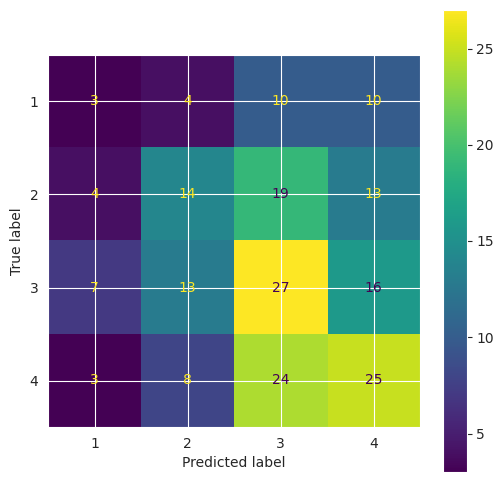

In [57]:
plot_confusion_matrix(cb_model, X_test, y_test)

Только у 3-его и 4-ого классов модель правильно предскзала большинство объектов классов. С 1-ым классом конечно проблемы, большинство его объеков расцениваются как объекты 3-его и 4-ого

## Многоклассификационная модель




Первая из моделей будет обучаться на векторную целевую переменную, которая будет строиться как количество единиц, равное номеру класса минус 1, и затем такого количества нулей, чтобы общая размерность вектора равнялось количеству класов минус 1

В качестве примера приведём то, как закодируются объекты с классами 2, 1, 4 и 3 соответственно:
$$\large{\begin{pmatrix} 1 \quad 0 \quad 0 \\ 0 \quad 0 \quad 0 \\ 1 \quad 1 \quad 1 \\ 1 \quad 1 \quad 0 \\\end{pmatrix}}$$

Здесь не вычисляются вероятности принадлежности к каждому классу (я решил не делать такой функционал), а вычисляются сами классы. Получаемый класс зависит от последней единички в ряду (единички/нолики получаются в зависимости от предсказанных вероятностей для векторной целевой переменной). Например, если она стоит на 2-ем месте, то это 3-ий класс, а если в ряду вообще нет единиц, то это будет 1-ый класс

In [58]:
class MultiLabelCatBoostClassifier(CatBoostClassifier):
    def __init__(self, *args, loss_function='MultiCrossEntropy', **kwargs):
        super().__init__(*args, loss_function=loss_function, **kwargs)

    @staticmethod
    def _make_y_2d(y):
        encoder = OneHotEncoder()
        y_2d = encoder.fit_transform(
            y.values.reshape(-1, 1)
        ).toarray().astype(int)
        mask = np.tile(np.arange(y.nunique()), (y.shape[0], 1)) < \
            np.argmax(y_2d, axis=1).reshape(-1, 1)
        y_2d[mask] = 1
        y_2d = pd.DataFrame(
            y_2d[:, 1:],
            index=y.index,
            columns=np.sort(y.unique())[:-1] + 1
        )
        return y_2d

    def fit(self, X, y, *args, **kwargs):
        self.max_ = y.max()
        y_2d = self._make_y_2d(y)
        super().fit(X, y_2d, *args, **kwargs)

    def predict(self, X, threshold=0.5):
        preds = np.hstack([
            np.ones((X.shape[0], 1)),
            (super().predict_proba(X) > threshold)
        ]).astype(int)[..., ::-1]
        preds = self.max_ - np.argmax(preds, axis=1)
        return preds

In [59]:
multilabel_model = optimize(MultiLabelCatBoostClassifier)

  0%|          | 0/50 [00:00<?, ?it/s]

In [60]:
metrics = get_metrics(multilabel_model, X_test, y_test, metrics=metrics)

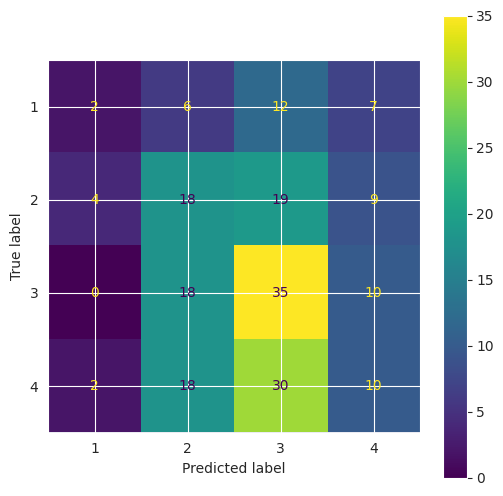

In [61]:
plot_confusion_matrix(multilabel_model, X_test, y_test)

У 1-ого класса теперь большинство его объектов расцениваются как 3-его, однако ухудшилась ситуация с 4-ым классом, теперь он тоже "сместился" в сторону 3-его класса

## Многоклассовая модель

Рассмотрим задачу с другой стороны - теперь для каждого класса $\large{k}$ от 1 до 4 включительно будем обучать модель на предсказание следующей величины: $$\large{P(y>k|y>k-1)}$$

Итого, всего будет по 3 модели и модель под номером $\large{k}$ будет обучаться только на тех данных, где класс $\large{y \geq k}$, причём если $\large{y = k}$, то целевая переменная равняется 0, в противном же случае она будет равняться 1

Но как же получается вероятность $\large{P(y=k)}$? Для этого сначала посчитаем следующую вероятность того, что класс больше класса $\large{k}$:
$$\large{P(y>k)=\prod_{j=1}^kP(y>j|y>j-1)}$$

В итоге искомая вероятность получается ледующим образом:
$$\large{P(y=k)=P(y>k-1)-P(y>k)}$$

И есть 2 частных случая:
$$\large{\begin{cases}P(y=4)=P(y>3) - P(y>4)=P(y>3) \\ P(y=1) = P(y>0) - P(y>1)= 1 - P(y>1)\end{cases}}$$

Вот так и вычисляют вероятности принадлежности к классам. Следует заметить, что здесь есть существенный минус, обычно вероятность какого-то класса почти равна 1, а остальные околонулевые

In [62]:
class MultiCatBoostClassifier:
    def __init__(self, **kwargs):
        self.kwargs_ = kwargs
        self.classifiers_ = {}

    def fit(self, X, y, *args, **kwargs):
        for unique_class in np.sort(y.unique())[:-1]:
            y_local = y[y >= unique_class]
            y_local = (y_local > unique_class).astype(int)
            X_local = X.loc[y_local.index]
            model = CalibratedClassifierCV(
                estimator=CatBoostClassifier(**self.kwargs_),
                cv=5,
                method='isotonic'
            )
            model.fit(X_local, y_local, *args, **kwargs)
            self.classifiers_[unique_class] = model

    def predict_proba(self, X):
        current = np.ones(X.shape[0])
        preds = [current]
        for key in sorted(self.classifiers_.keys()):
            local_preds = self.classifiers_[key].predict_proba(X)[:, 1].ravel()
            current = current * local_preds
            preds.append(current)
        preds.append(np.zeros(X.shape[0]))
        preds = np.array(preds)
        preds = (preds[:-1] - preds[1:]).T
        return preds

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1) + 1

In [63]:
multi_model = optimize(MultiCatBoostClassifier)

  0%|          | 0/50 [00:00<?, ?it/s]

In [64]:
metrics = get_metrics(multi_model, X_test, y_test, metrics=metrics)

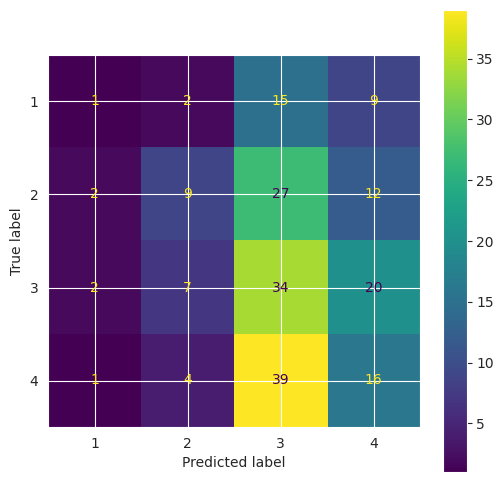

In [65]:
plot_confusion_matrix(multi_model, X_test, y_test)

Ну тут 3-ий класс задоминировал всё и вся, а у 1-ого класса правильно предсказан лишь 1 объект

## Пороговая модель

Ну и последний подход - пороговый

Сначала обучаем обычный регрессор на целевую переменную, а дальше нам нужно установить пороги и класс объекта зависит от того, между какими порогами он находится

В качестве изначального приближения установим пороги следующим образом - у нас есть $\large{k_1}$ реальных объектов первого класса, значит в отсортированном массиве предсказаний после первых $\large{k_1}$ ставим порог - он отделяет объекты первого и второго классов. Далее, допустим, у нас есть $\large{k_2}$ реальных объектов второго класса, тогда спустя ещё $\large{k_2}$ предсказанных объектов ставим порог, отделяющий объекты второго и третьего класса

Итак, у нас есть изначальное пороговое приближение - а далее мы неградиентным [методом Нелдера-Мида](http://www.machinelearning.ru/wiki/index.php?title=%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%9D%D0%B5%D0%BB%D0%B4%D0%B5%D1%80%D0%B0-%D0%9C%D0%B8%D0%B4%D0%B0) подбираем оптимальные пороги таким образом, чтобы значение каппы Коэна было минимальным

In [79]:
class ThresholdCatBoostRegressor(CatBoostRegressor):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    @staticmethod
    def _get_initial_thresholds(y, preds):
        class_proportions = (y.value_counts().sort_index() / y.shape[0]).values
        cumulative_proportions = np.cumsum(class_proportions)[:-1]
        thresholds = np.quantile(preds, cumulative_proportions)
        return thresholds

    @staticmethod
    def _digitize(y_pred, thresholds):
        sorted_thresholds = np.sort(thresholds)
        return np.digitize(y_pred, sorted_thresholds) + 1

    @staticmethod
    def _loss(thresholds, y_pred, y_true):
        y_discrete = ThresholdCatBoostRegressor._digitize(y_pred, thresholds)
        qwk = cohen_kappa_score(y_true, y_discrete, weights='quadratic')
        return -qwk

    def fit(self, X, y, *args, **kwargs):
        super().fit(X, y, *args, **kwargs)
        preds = super().predict(X)
        thresholds = self._get_initial_thresholds(y, preds)
        result = minimize(
            fun=self._loss,
            x0=thresholds,
            args=(preds, y),
            method='Nelder-Mead'
        )
        self.thresholds_ = np.sort(result.x)

    def predict(self, X, *args, **kwargs):
        preds = super().predict(X, *args, **kwargs)
        return self._digitize(preds, self.thresholds_)

In [85]:
threshold_model = optimize(ThresholdCatBoostRegressor)

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
metrics = get_metrics(threshold_model, X_test, y_test, metrics=metrics)

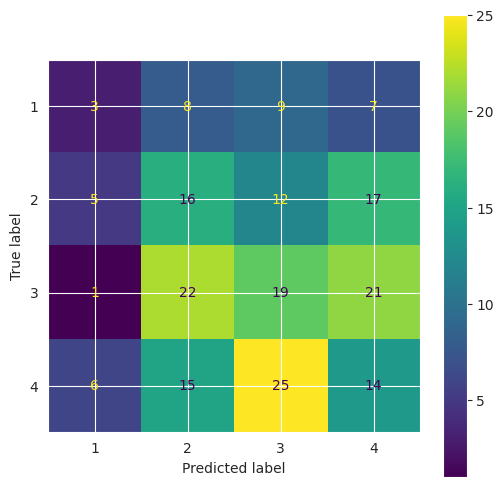

In [86]:
plot_confusion_matrix(threshold_model, X_test, y_test)

4-ый класс снова ошибся в сторону 3-его, а сам 3-ий в сторону 2-ого и 4-ого, 2-ой класс часто ошибался в сторону 3-его и 4-ого, а у 1-ого класса аж цельных 3 объекта предсказаны правильно - успех

В общем, ни один класс не был правильно предсказан в большинстве - никто не ушёл обиженным

# Выводы

Что ж, так бывает, что самая простая модель является наилучшим выбором - так и проиошло в этот раз. Ни одно из улучшений по любым метрикам не превосходит божественный оригинал

In [70]:
metrics

,accuracy,precision,recall,f1,cohen kappa
CatBoostClassifier,0.345,0.315892,0.309087,0.307955,0.093601
MultiLabelCatBoostClassifier,0.325,0.298090,0.289074,0.272536,0.013398
MultiCatBoostClassifier,0.300,0.288028,0.255847,0.241533,0.036603
ThresholdCatBoostRegressor,0.260,0.247973,0.241508,0.240829,0.015420
